In [2]:
import torch
import torch.nn.functional as F
import numpy as np
from scipy.interpolate import PchipInterpolator
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from scipy.interpolate import interp1d
import math
import os
import torch.nn.functional as F
from ultralytics import YOLO
from PIL import Image, ImageDraw

## ORB: поиск ключевых точек изображения

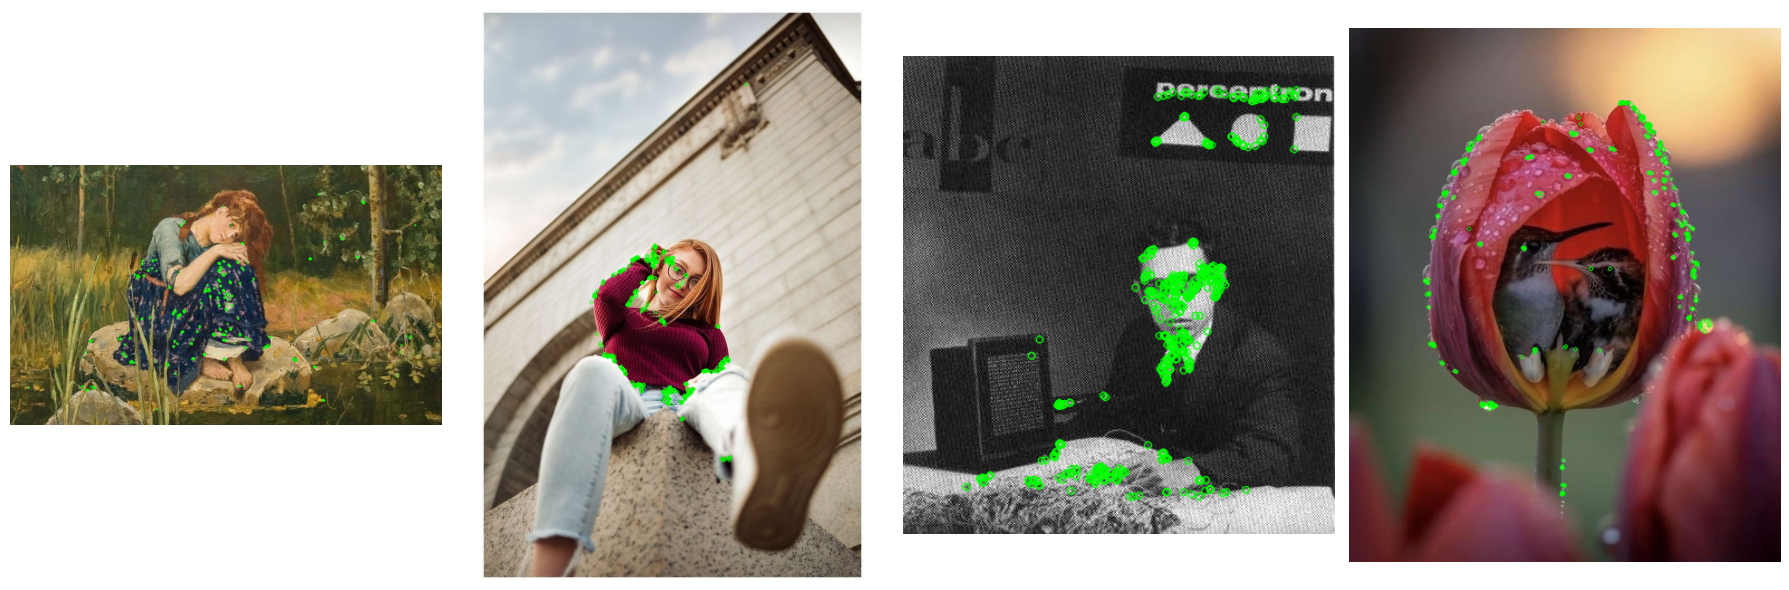

In [129]:
# Использование ORB (Oriented FAST and rotated BRIEF) для поиска ключевых точек
# Суть метода: ORB определяет ключевые точки так: 
# большинство соседей сильно различаются в яркости с выбранным центральным пикселем 
# (обычно круг 16 пикселей), выше порога интенсивности. 
# Применяется для разных масштабов изображения, чтобы установить, что выбранная ключевая точка инвариантна к изменениям масштаба
# Проверяется, сохраняется ли значимое превышение порога при повороте изображения и при разных степенях размытия

imgs = ["1.jpg", "photo_woman.jpg", "Rosenblatt.jpg", "photo.jpg"]
orb = cv2.ORB_create()
fig, axes = plt.subplots(1, 4, figsize=(18,6))
for ax, img in zip(axes, imgs):
    image = Image.open(img)
    grey_img_pil = image.convert("L")
    grey_img = cv2.imread(img)
    img_norm = cv2.cvtColor(grey_img, cv2.COLOR_BGR2RGB)
    keypoints, descr = orb.detectAndCompute(img_norm, None)
    # Координаты keypoints
    coords_all = []
    for kp in keypoints:
        x, y = kp.pt[0], kp.pt[1]
        pixel = grey_img_pil.getpixel((x, y))
        coords_all.append([[x, y], pixel])
    res = cv2.drawKeypoints(img_norm, keypoints, None, color=(0, 255, 0))
    ax.imshow(res)
    ax.axis("off")
fig.tight_layout()
# plt.savefig("orb_feat_result.png", dpi=350)
# print("Результат сохранён: orb_feat_result.png")

## ORB + размытие по эксцентриситету + яркость адаптации

In [3]:
# Параметры экрана и зрения
screen_width = 600      # мм
view_dist = 600         # мм
base_sigma = 0.2        # минимальное размытие (фовеола)
scale_density = 150.0   # коэффициент влияния плотности

# Таблица плотности RGC (клеток/мм^2) от эксцентриситета на сетчатке (мм)
ecc_mm_data = np.array([0.0, 0.25, 1.5, 4.0, 5.0, 9.0, 15.0, 17.0])
density_data = np.array([200000, 38000, 18000, 5000, 3900, 1000, 800, 400])

density_interp = interp1d(
    ecc_mm_data, density_data,
    kind='linear',
    bounds_error=False,
    fill_value=(density_data[0], density_data[-1])
)

# Карта яркости (Luminance)
def get_luminance(img_rgb):
    return np.dot(img_rgb[..., :3], [0.2126, 0.7152, 0.0722])

def calculate_deg_per_px(screen_w, view_dist, img_w):
    half_width_mm = screen_w / 2.0
    angle_rad = math.atan(half_width_mm / view_dist)
    full_angle_deg = 2 * angle_rad * (180.0 / math.pi)
    return full_angle_deg / img_w

def mm_from_deg(ecc_deg):
    return ecc_deg * 0.288 # Приблизительный масштаб сетчатки

def sigma_from_density(density_val):
    spacing = 1.0 / np.sqrt(np.maximum(density_val, 1.0))
    return base_sigma + scale_density * spacing

def eccentricity_blur_with_density(img, center, deg_per_px):
    h, w = img.shape[:2]
    
    # Карта расстояний в пикселях от центра
    y, x = np.ogrid[:h, :w]
    dist_px = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    
    # Перевод в градусы зрительного угла
    ecc_deg_map = dist_px * deg_per_px
    
    # Перевод в мм на сетчатке
    ecc_mm_map = mm_from_deg(ecc_deg_map)
    
    # Карта плотности RGC
    density_map = density_interp(ecc_mm_map)
    
    # Карта Sigma (размытия)
    sigma_map = sigma_from_density(density_map)
    
    # Оптимизированное размытие:
    # Так как GaussianBlur дорогой, мы не можем делать его для каждого пикселя.
    # Поэтому усредненный подход по зонам или адаптивное ядро.
    # Для простоты и скорости сделаем дискретизацию по уровням sigma.
    
    unique_sigmas = np.unique(np.round(sigma_map, 1))
    result = np.zeros_like(img, dtype=np.float64)
    weight = np.zeros((h, w), dtype=np.float64)
    
    # Группируем похожие сигмы, чтобы не делать 100 разных блюров
    # Шаг квантования сигмы
    step = 0.5 
    min_s = np.min(sigma_map)
    max_s = np.max(sigma_map)
    
    current_sigma = min_s
    while current_sigma <= max_s:
        next_sigma = current_sigma + step
        # Маска для текущей полосы сигм
        mask = (sigma_map >= current_sigma) & (sigma_map < next_sigma)
        
        if np.any(mask):
            ksize = int(6 * current_sigma + 1) | 1
            ksize = max(3, ksize)
            
            # Размываем все изображение с текущей сигмой
            blurred_patch = cv2.GaussianBlur(img, (ksize, ksize), sigmaX=current_sigma)
            
            result[mask] += blurred_patch[mask]
            weight[mask] += 1.0
            
        current_sigma = next_sigma
        
    # Нормализация (на случай перекрытий, хотя здесь они исключены масками)
    weight = np.maximum(weight, 1e-6)
    final_img = result / weight[..., None]
    
    return np.clip(final_img, 0, 255).astype(np.uint8), ecc_deg_map, density_map
    
# Размытие
# blurred_image, ecc_map, dens_map = eccentricity_blur_with_density(image_rgb, center, deg_per_px)

In [130]:
def calculate_luminance_adaptation_from_key_points(coords, den_map): 
    """
    Рассчитывает яркость адаптации изображения на основе данных ключевых точек (метод ORB)
    Аргументы:
        coords: координаты ключевых точек ([x, y], pixel_l_blurred)
        lum_map: карта освещения
        den_map: карта плотности RGC
        
    Returns:
        Яркость адаптации: float
    """
    total_weight = 0.00
    total_lum = 0.00
    
    for coord, pixel in coords:
            
            x, y = int(coord[0]), int(coord[1])
        
            zone_den = den_map[y, x]
        
            total_weight += zone_den
    
            total_lum += pixel * zone_den
    
    if total_weight == 0: 
        return 0, zone_den
        
    return total_lum / total_weight

In [132]:
# Сортировка по яркости ключевых точек
# Первые 10 для отображения с помощью библиотеки Pillow
# На каждом изображении находятся ключевые точки методом ORB
# Далее находятся координаты ключевых точек
# Далее топ-10 по яркости точек отображаются на изображении
coords_all = []
for num, img in enumerate(imgs):
    grey_img = cv2.imread(img, cv2.IMREAD_GRAYSCALE)
    image_rgb = cv2.cvtColor(grey_img, cv2.COLOR_GRAY2RGB)
    img_pil = Image.open(img)
    grey_img_pil = img_pil.convert("L")
    keypoints, _ = orb.detectAndCompute(grey_img, None)
    # Координаты keypoints
    coords_all.append([])
    
    for kp in keypoints:
        x, y = kp.pt[0], kp.pt[1]
        pixel = grey_img_pil.getpixel((x, y))
        coords_all[num].append([[x, y], pixel])
        
    coords_all[num].sort(key = lambda n: n[1], reverse=True)
    # draw = ImageDraw.Draw(img_pil)
    # for coord, l in coords_all[num][:11]:
    #     x, y = coord[0], coord[1]
    #     draw.ellipse([x-5, y-5, x+5, y+5], 
    #                  fill='red', outline='red')
    # # img_pil.show()

    h, w = image_rgb.shape[:2]
    center = (w // 2, h // 2)
    deg_per_px = calculate_deg_per_px(screen_width, view_dist, w)
    print(f"Изображение {num}: Размер: {w}x{h}, Центр: {center}, Deg/Px: {deg_per_px:.4f}")
    
    blurred_image, ecc_map, dens_map = eccentricity_blur_with_density(image_rgb, center, deg_per_px)
    blurred_image_pil = Image.fromarray(blurred_image)

    pixel_ls = []
    for val in coords_all[num][:50]:
        x, y, pixel = val[0][0], val[0][1], val[1]
        pixel_blurred = blurred_image[int(y), int(x)][0]
        pixel_ls.append([[x, y], pixel_blurred])

    l_a = calculate_luminance_adaptation_from_key_points(pixel_ls, dens_map)
    print(f"Яркость адаптации для изображения {num}: {l_a:.3f}")

Изображение 0: Размер: 1280x770, Центр: (640, 385), Deg/Px: 0.0415
Яркость адаптации для изображения 0: 191.262
Изображение 1: Размер: 736x1098, Центр: (368, 549), Deg/Px: 0.0722
Яркость адаптации для изображения 1: 205.752
Изображение 2: Размер: 387x429, Центр: (193, 214), Deg/Px: 0.1373
Яркость адаптации для изображения 2: 183.684
Изображение 3: Размер: 736x913, Центр: (368, 456), Deg/Px: 0.0722
Яркость адаптации для изображения 3: 165.737


## Выделение зон внимания: YOLO

In [4]:
# !pip install ultralytics

In [69]:
# ============================================================
# МОДУЛЬ БИОЛОГИЧЕСКОГО РАЗМЫТИЯ И ПЛОТНОСТИ
# ============================================================
class BioAdaptiveBrightness(torch.nn.Module):
    """
    Вычисление яркости адаптации = средневзвешеннео значение
    яркости пикселей внутри масок объектов.
    
    Вес каждого пикселя зависит от плотности RGC в точке его расположения.
    Результат приводится к шкале [0, 255].
    """

    def __init__(self, img_width_deg: float = 40.0,
                 monitor_diagonal_inch: float = 24.0,
                 aspect_ratio: float = 16 / 9):
        super().__init__()
        self.img_width_deg = img_width_deg
        diag_mm = monitor_diagonal_inch * 25.4
        self.monitor_width_mm = diag_mm / np.sqrt(1 + (1 / aspect_ratio) ** 2)

        # Таблица плотности ганглиозных клеток, кл/мм^2
        self.ecc_mm = np.array([0.0, 0.3, 1.5, 4.5, 9.0, 15.0])
        self.density_rgc = np.array([200000, 35000, 16500, 3400, 1000, 800])
        self.interp_func = PchipInterpolator(self.ecc_mm, self.density_rgc)
        self.max_density = 200000.0

    def _get_density_weight(self, x_px: float, y_px: float, h: int, w: int) -> float:
        """Получить вес на основе плотности RGC для данной позиции."""
        dist_px = np.sqrt((x_px - w / 2) ** 2 + (y_px - h / 2) ** 2)
        dist_deg = (dist_px / w) * self.img_width_deg
        ecc_mm = dist_deg * (17.0 / 57.2958)
        density = self.interp_func(ecc_mm)
        return float(density / self.max_density)

    def forward(self, image: torch.Tensor,
                masks: list[torch.Tensor],
                centers: list[tuple[float, float]]) -> torch.Tensor:
        """
        Аргумеенты:
            image: [B, C, H, W] тензор изображения в диапазоне [0, 1]
            masks: список бинарных масок [H, W]
            centers: список центров (cx, cy) для каждой маски
        
         На выходе Яркость адаптации в диапазоне [0, 255]
        """
        B, C, H, W = image.shape
        device = image.device

        weighted_brightness_sum = torch.tensor(0.0, device=device)
        total_weight = torch.tensor(0.0, device=device)

        for i in range(len(masks)):
            mask_i = masks[i].unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
            cx, cy = centers[i]

            # Получаем вес на основе центра объекта
            weight = self._get_density_weight(cx, cy, H, W)

            # Вычисляем среднюю яркость внутри маски
            # Для цветного изображения берем среднее по каналам
            if C == 3:
                # Конвертируем в grayscale для получения яркости
                # Используем стандартные коэффициенты luminance
                gray_image = (0.299 * image[:, 0:1, :, :] + 
                            0.587 * image[:, 1:2, :, :] + 
                            0.114 * image[:, 2:3, :, :])
            else:
                gray_image = image.mean(dim=1, keepdim=True)

            # Маскируем изображение
            masked_gray = gray_image * mask_i
            
            # Сумма яркостей и количество пикселей в маске
            brightness_sum = masked_gray.sum()
            pixel_count = mask_i.sum()

            if pixel_count > 0:
                avg_brightness = brightness_sum / pixel_count
                weighted_brightness_sum += avg_brightness * weight * pixel_count
                total_weight += weight * pixel_count

        # Средневзвешенная яркость
        if total_weight > 0:
            avg_luminance = weighted_brightness_sum / total_weight
            # Приводим к диапазону [0, 255]
            adaptation_brightness = torch.clamp(avg_luminance * 255.0, min=0.0, max=255.0)
        else:
            adaptation_brightness = torch.tensor(0.0, device=device)

        return adaptation_brightness.squeeze()


# ============================================================
# МОДУЛЬ ВЫДЕЛЕНИЯ ОБЪЕКТОВ (YOLOv8-seg)
# ============================================================
def detect_objects(image_bgr: np.ndarray,
                   model_path: str = "yolov8n-seg.pt",
                   conf_threshold: float = 0.1):
    """Возвращает маски и центры масс, 
    приведённые к размеру исходного изображения."""
    model = YOLO(model_path)
    results = model(image_bgr, conf=conf_threshold, verbose=False)

    masks, centers, boxes, labels = [], [], [], []
    h, w = image_bgr.shape[:2]

    for r in results:
        if r.masks is None:
            continue

        orig_h, orig_w = r.masks.orig_shape[0], r.masks.orig_shape[1]

        for idx, mask_tensor in enumerate(r.masks.data):
            mask_np = mask_tensor.cpu().numpy()
            # ресайз до реальных размеров изображения
            mask_resized = cv2.resize(mask_np, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
            bin_mask = (mask_resized > 0.5).astype(np.uint8)

            if bin_mask.sum() == 0:
                continue

            ys, xs = np.where(bin_mask > 0)
            cx = float(xs.mean())
            cy = float(ys.mean())

            masks.append(torch.from_numpy(bin_mask).float())
            centers.append((cx, cy))
            boxes.append(r.boxes.xyxy[idx].cpu().numpy())
            labels.append(int(r.boxes.cls[idx].item()))

    return masks, centers, boxes, labels


# ============================================================
# ПАЙПЛАЙН
# ============================================================
def pipeline(image_path: str):
    # Загрузка и подготовка изображения
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Не найден файл: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_norm = img_rgb.astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img_norm).permute(2, 0, 1).unsqueeze(0)

    # Детекция объектов
    masks, centers, boxes, labels = detect_objects(img_bgr)
    print(f"Найдено объектов (AOI): {len(masks)}")
    for i, (c, lbl) in enumerate(zip(centers, labels)):
        print(f"  AOI {i}: класс={lbl}, центр=({c[0]:.0f}, {c[1]:.0f})")

    if len(masks) == 0:
        print("Объекты не обнаружены. Попробуйте снизить conf_threshold.")
        return

    # Расчет яркости адаптации
    bio_blur = BioAdaptiveBrightness(img_width_deg=40.0)
    with torch.no_grad():
        adaptation_lum = bio_blur(img_tensor, masks, centers)

    print(f"\nL_a = {adaptation_lum.item():.2f} / 255.0 ")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Оригинал")
    axes[0].axis('off')

    overlay = img_rgb.copy()
    for m in masks:
        m_np = m.numpy()
        overlay[m_np > 0] = [255, 100, 0]
    axes[1].imshow(overlay)
    axes[1].set_title(f"Выделенные зоны внимания ({len(masks)} шт.)")
    axes[1].axis('off')

    plt.suptitle(f"L_a = {adaptation_lum.item():.2f}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

Найдено объектов (AOI): 1
  AOI 0: класс=0, центр=(569, 381)

L_a = 92.43 / 255.0 


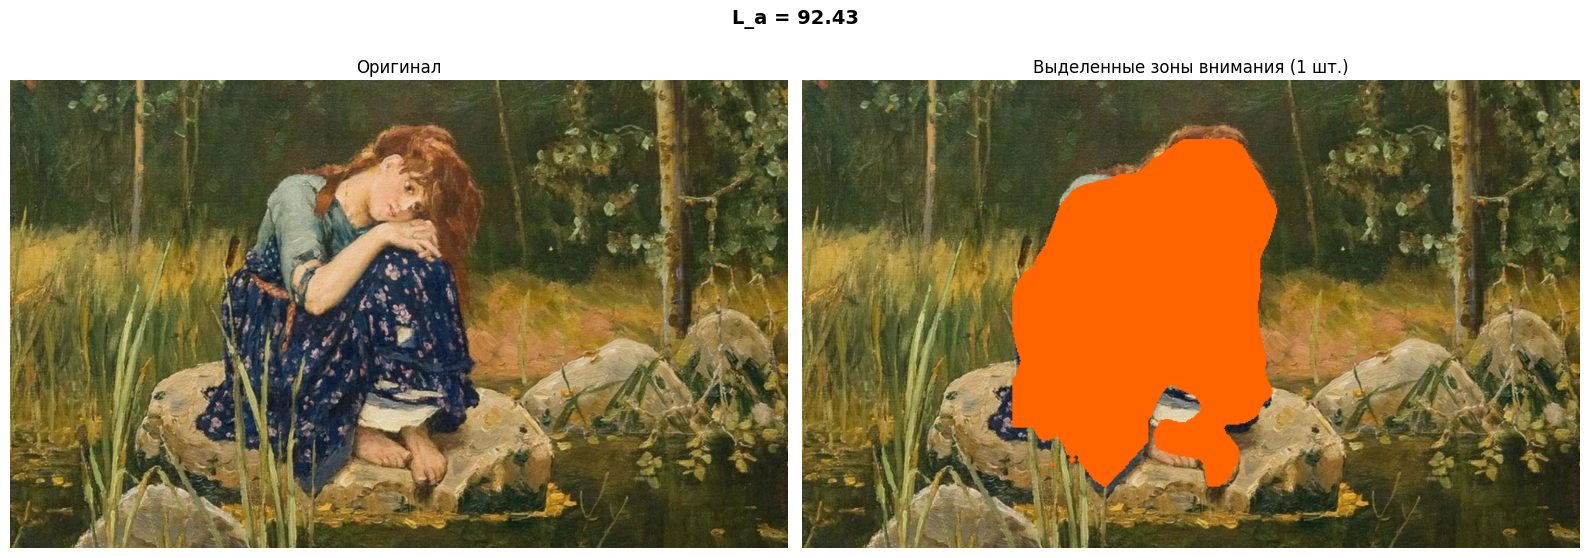

In [70]:
pipeline("1.jpg")

Найдено объектов (AOI): 1
  AOI 0: класс=0, центр=(390, 765)

L_a = 115.43 / 255.0 


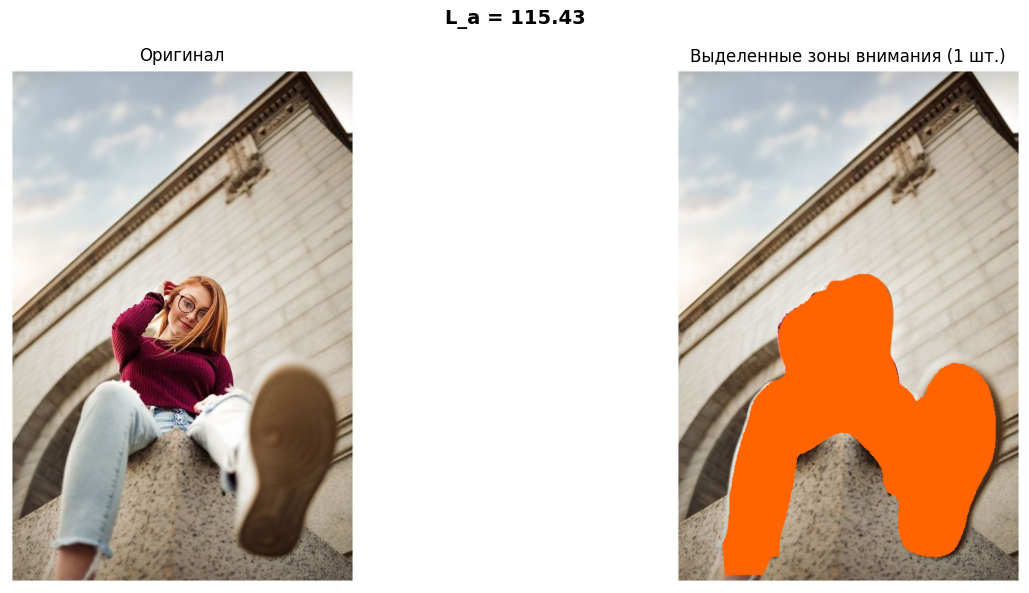

In [71]:
pipeline("photo_woman.jpg")

Найдено объектов (AOI): 15
  AOI 0: класс=0, центр=(416, 285)
  AOI 1: класс=0, центр=(103, 309)
  AOI 2: класс=0, центр=(687, 279)
  AOI 3: класс=0, центр=(554, 285)
  AOI 4: класс=0, центр=(281, 261)
  AOI 5: класс=0, центр=(407, 110)
  AOI 6: класс=0, центр=(72, 154)
  AOI 7: класс=0, центр=(206, 209)
  AOI 8: класс=0, центр=(622, 206)
  AOI 9: класс=0, центр=(614, 132)
  AOI 10: класс=27, центр=(217, 306)
  AOI 11: класс=0, центр=(70, 156)
  AOI 12: класс=27, центр=(214, 294)
  AOI 13: класс=27, центр=(490, 371)
  AOI 14: класс=26, центр=(216, 313)

L_a = 99.78 / 255.0 


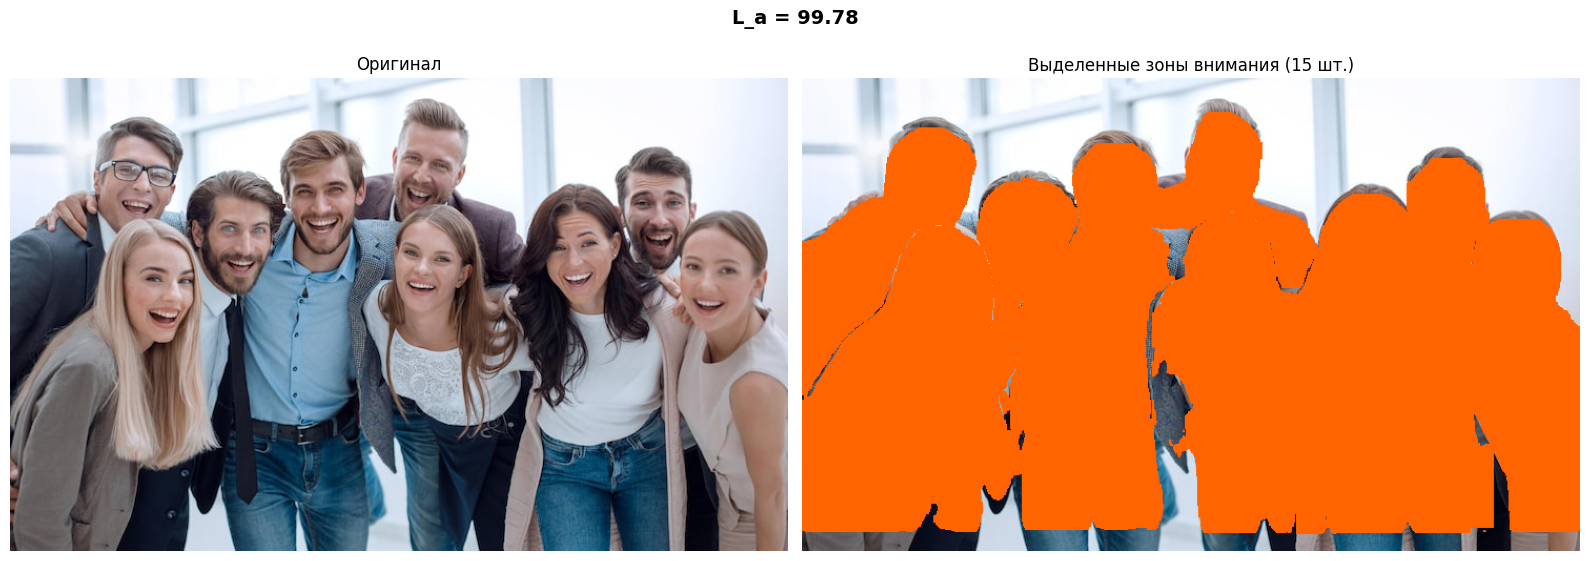

In [72]:
pipeline("f.jpg")

Найдено объектов (AOI): 6
  AOI 0: класс=54, центр=(359, 403)
  AOI 1: класс=47, центр=(234, 828)
  AOI 2: класс=0, центр=(593, 729)
  AOI 3: класс=0, центр=(233, 828)
  AOI 4: класс=0, центр=(397, 603)
  AOI 5: класс=48, центр=(359, 412)

L_a = 72.55 / 255.0 


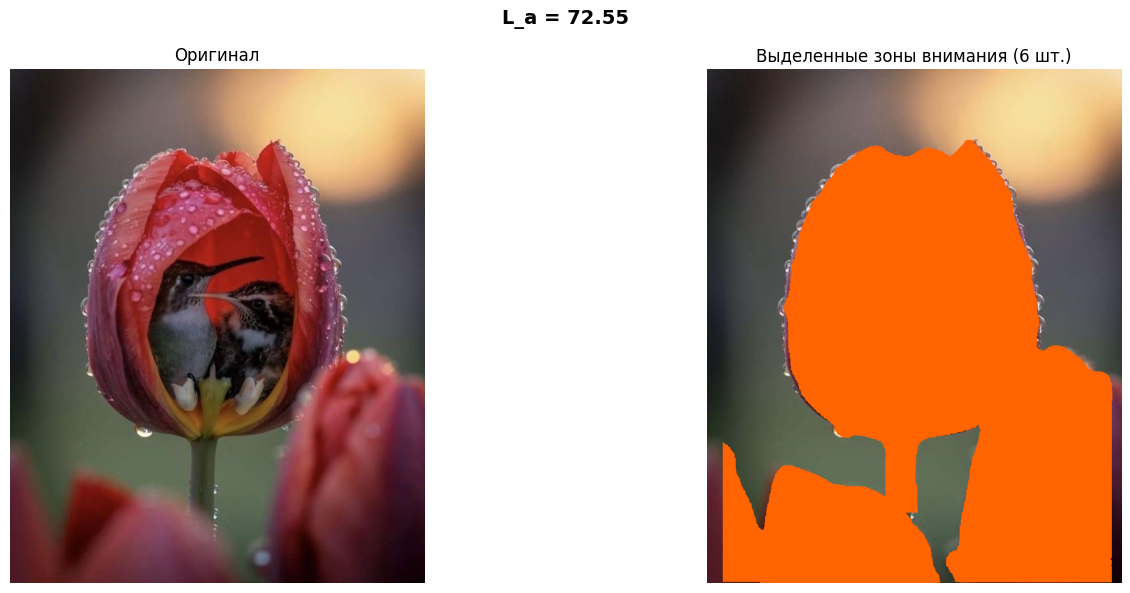

In [73]:
pipeline("photo.jpg")

Найдено объектов (AOI): 8
  AOI 0: класс=0, центр=(244, 326)
  AOI 1: класс=0, центр=(264, 288)
  AOI 2: класс=27, центр=(240, 284)
  AOI 3: класс=15, центр=(188, 396)
  AOI 4: класс=27, центр=(237, 279)
  AOI 5: класс=74, центр=(304, 68)
  AOI 6: класс=56, центр=(85, 313)
  AOI 7: класс=59, центр=(190, 396)

L_a = 91.22 / 255.0 


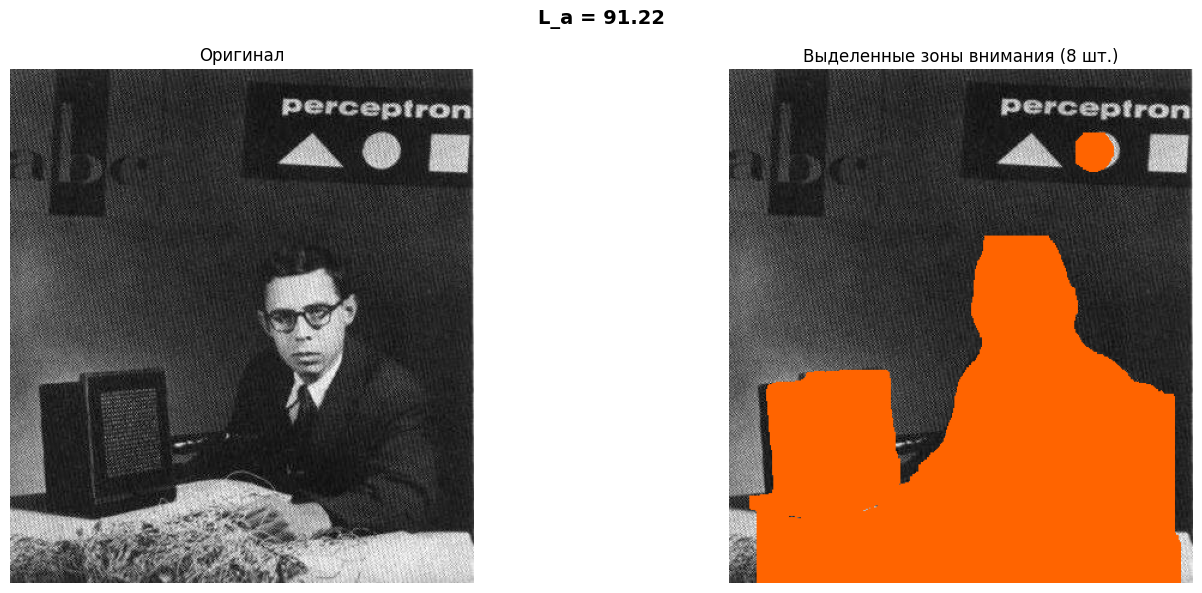

In [74]:
pipeline("Rosenblatt.jpg")

## Поиск и выделение зон внимания: FineGrained и SpectralResidual (openCV)

In [6]:
img_path = str(input())
image = cv2.imread(str(img_path))
if image is None:
    raise FileNotFoundError("Не удалось загрузить изображение")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("StaticSaliency FineGrained метод")
saliency_fg = cv2.saliency.StaticSaliencyFineGrained_create()
(success_fg, saliencyMap_fg) = saliency_fg.computeSaliency(image)

print("StaticSaliency SpectralResidual метод")
saliency_sr = cv2.saliency.StaticSaliencySpectralResidual_create()
(success_sr, saliencyMap_sr) = saliency_sr.computeSaliency(image)

def find_objects_from_saliency(saliency_map, image_rgb, max_objects=10):
    """Находит объекты на основе карты значимости"""
    if saliency_map is None:
        return [], None
    
    # Нормализация к 0-255
    saliency_normalized = (saliency_map * 255).astype("uint8")
    
    # Бинаризация
    thresh = cv2.threshold(saliency_normalized, 0, 255, 
                          cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
    
    # Нахождение контуров карт значимости
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Сортировка по площади
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:max_objects]
    
    # bounding boxes для карт значимости
    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        boxes.append((x, y, w, h))
    
    return boxes, saliency_normalized

boxes_fg, saliency_norm_fg = find_objects_from_saliency(saliencyMap_fg, image_rgb, 10)
boxes_sr, saliency_norm_sr = find_objects_from_saliency(saliencyMap_sr, image_rgb, 10)

print(f"FineGrained: найдено {len(boxes_fg)} объектов")
print(f"SpectralResidual: найдено {len(boxes_sr)} объектов")

 photo.jpg


StaticSaliency FineGrained метод
StaticSaliency SpectralResidual метод
FineGrained: найдено 10 объектов
SpectralResidual: найдено 7 объектов


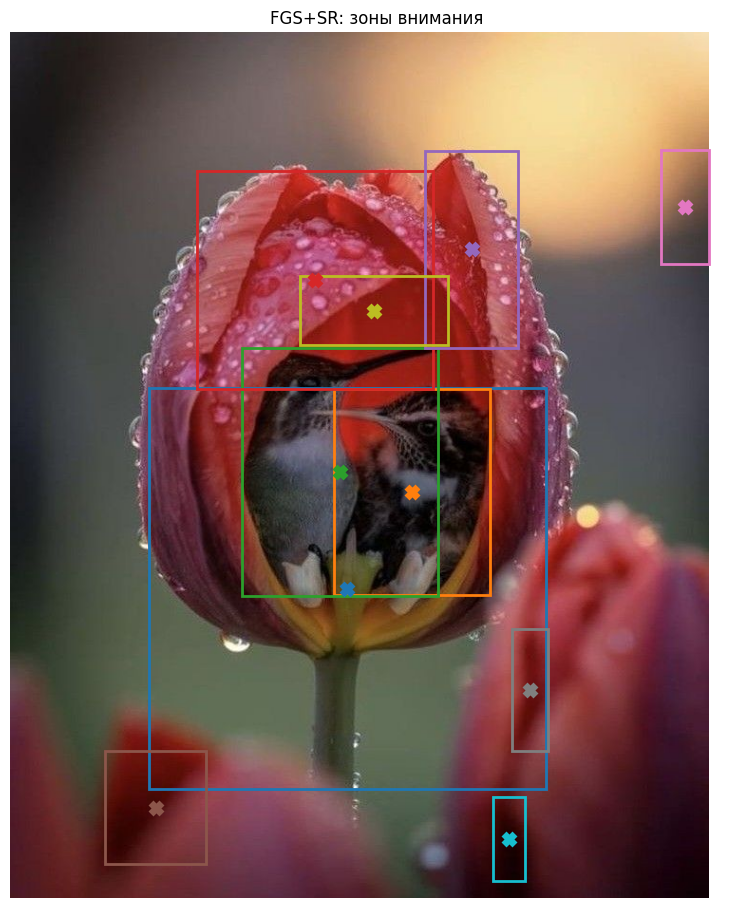

In [7]:
fig, ax = plt.subplots(figsize=(8, 10))
ax.imshow(image_rgb)

colors = plt.cm.tab10(np.linspace(0, 1, len(boxes_fg)))

for i, (x, y, w, h) in enumerate(boxes_fg):
    
    color = colors[i]
    rect = plt.Rectangle(
    (x, y), w, h, 
    linewidth=2, 
    edgecolor=color, 
    facecolor='none',
    label=f'Zone {i+1} ({w}x{h})'
    )
    ax.add_patch(rect)
    
    center_x = x + w / 2
    center_y = y + h / 2
    
    ax.plot(center_x, center_y, marker='X', color=color, 
            markersize=8, markeredgewidth=2)
    
    # ax.text(x, y - 5, f'#{i+1}', color=color, 
    #         fontsize=10, fontweight='bold', ha='center')

plt.tight_layout()
# plt.legend(loc='upper right', fontsize=9)
plt.title('FGS+SR: зоны внимания', fontsize=12)
plt.axis("off")
plt.show()

ValueError: num must be an integer with 1 <= num <= 9, not 10

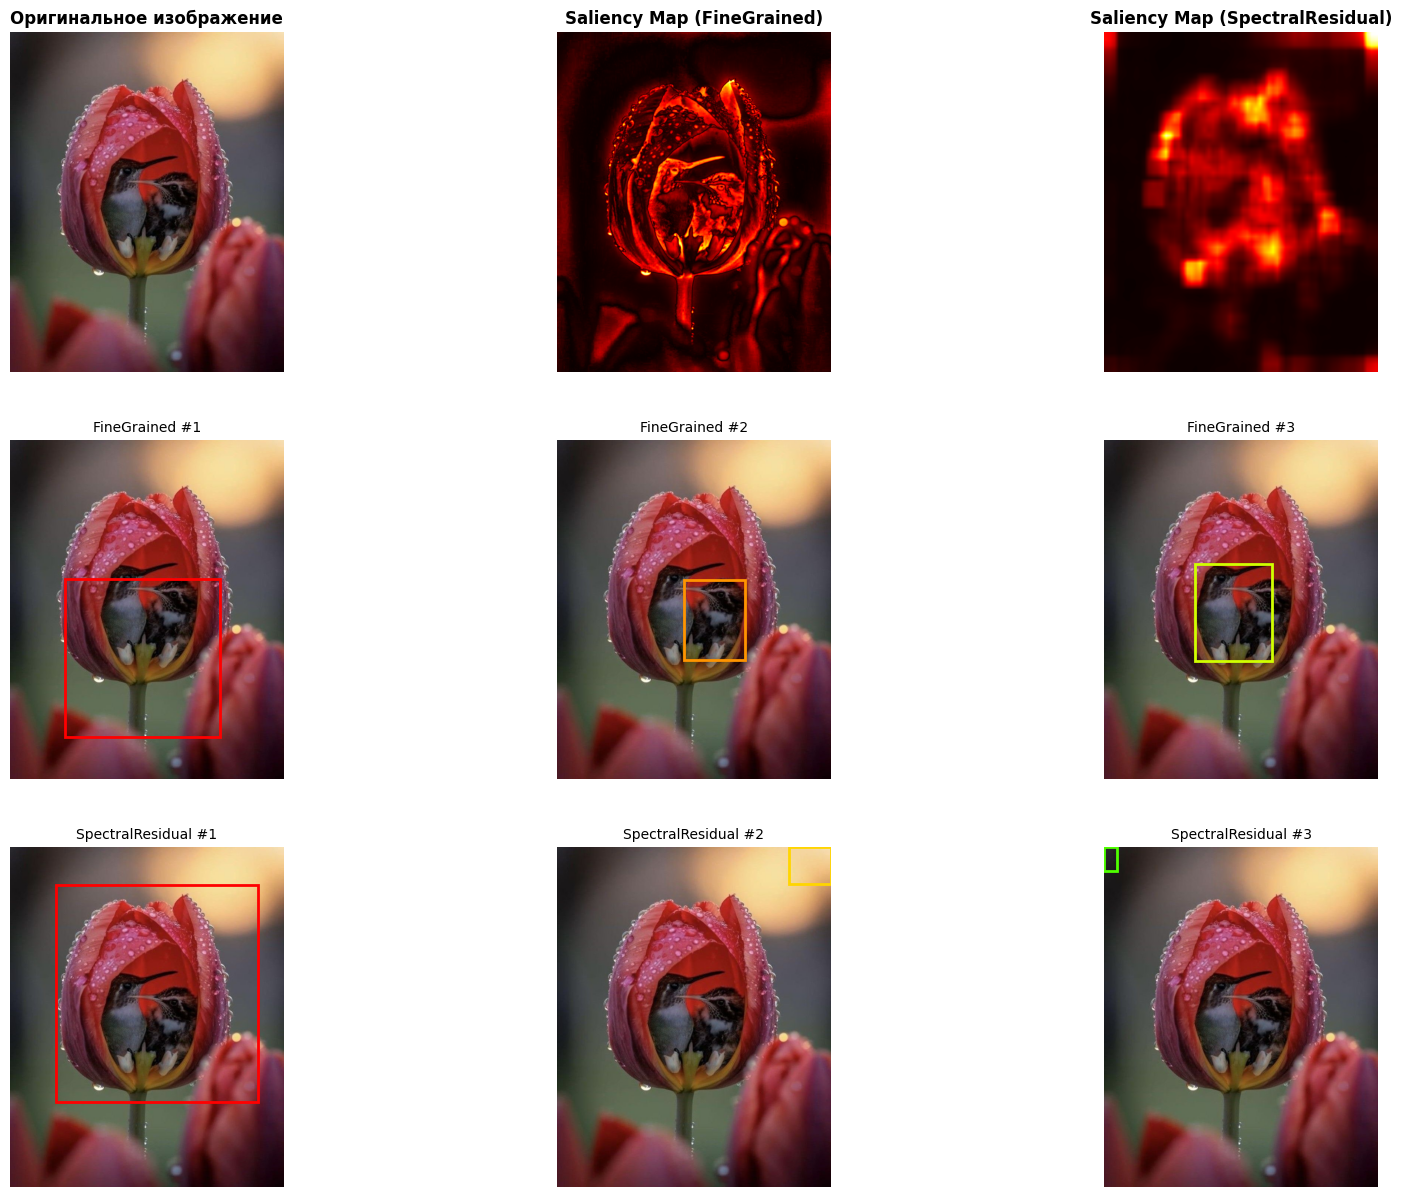

In [9]:
fig = plt.figure(figsize=(20, 15))

ax1 = plt.subplot(3, 3, 1)
ax1.imshow(image_rgb)
ax1.set_title('Оригинальное изображение', fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = plt.subplot(3, 3, 2)
if saliency_norm_fg is not None:
    ax2.imshow(saliency_norm_fg, cmap='hot')
    ax2.set_title('Saliency Map (FineGrained)', fontsize=12, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'Failed', ha='center', va='center')
ax2.axis('off')

ax3 = plt.subplot(3, 3, 3)
if saliency_norm_sr is not None:
    ax3.imshow(saliency_norm_sr, cmap='hot')
    ax3.set_title('Saliency Map (SpectralResidual)', fontsize=12, fontweight='bold')
else:
    ax3.text(0.5, 0.5, 'Failed', ha='center', va='center')
ax3.axis('off')

for i in range(min(3, len(boxes_fg))):
    ax = plt.subplot(3, 3, 4 + i)
    output = image_rgb.copy()
    x, y, w, h = boxes_fg[i]
    color = plt.cm.hsv(i / max(1, len(boxes_fg)))[:3]
    
    rect = plt.Rectangle((x, y), w, h, linewidth=2, 
                         edgecolor=color, facecolor='none')
    ax.imshow(output)
    ax.add_patch(rect)
    ax.set_title(f'FineGrained #{i+1}', fontsize=10)
    ax.axis('off')

for i in range(min(5, len(boxes_sr))):
    ax = plt.subplot(3, 3, 7 + i)
    output = image_rgb.copy()
    x, y, w, h = boxes_sr[i]
    color = plt.cm.hsv(i / max(1, len(boxes_sr)))[:3]
    
    rect = plt.Rectangle((x, y), w, h, linewidth=2, 
                         edgecolor=color, facecolor='none')
    ax.imshow(output)
    ax.add_patch(rect)
    ax.set_title(f'SpectralResidual #{i+1}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
# plt.savefig('saliency_detection_results.png', dpi=150, bbox_inches='tight')
plt.show()

plt.tight_layout()
# plt.savefig('saliency_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# print("\nРезультаты сохранены:")
# print("- saliency_detection_results.png")
# print("- saliency_histograms.png")

## FineGrained и SpectralResidual + размытие по эксцентриситету + яркость адаптации

Путь к изображению (или Enter для синтетики):  Rosenblatt.jpg


Изображение загружено.
Вычисление StaticSaliency FineGrained...
Вычисление StaticSaliency SpectralResidual...
Найдено 18 зон внимания (FineGrained) и 6 зон внимания (SpectralResidual)
Размер: 387x429, Центр: (193, 214), Deg/Px: 0.1373
Яркость адаптации = 78.56


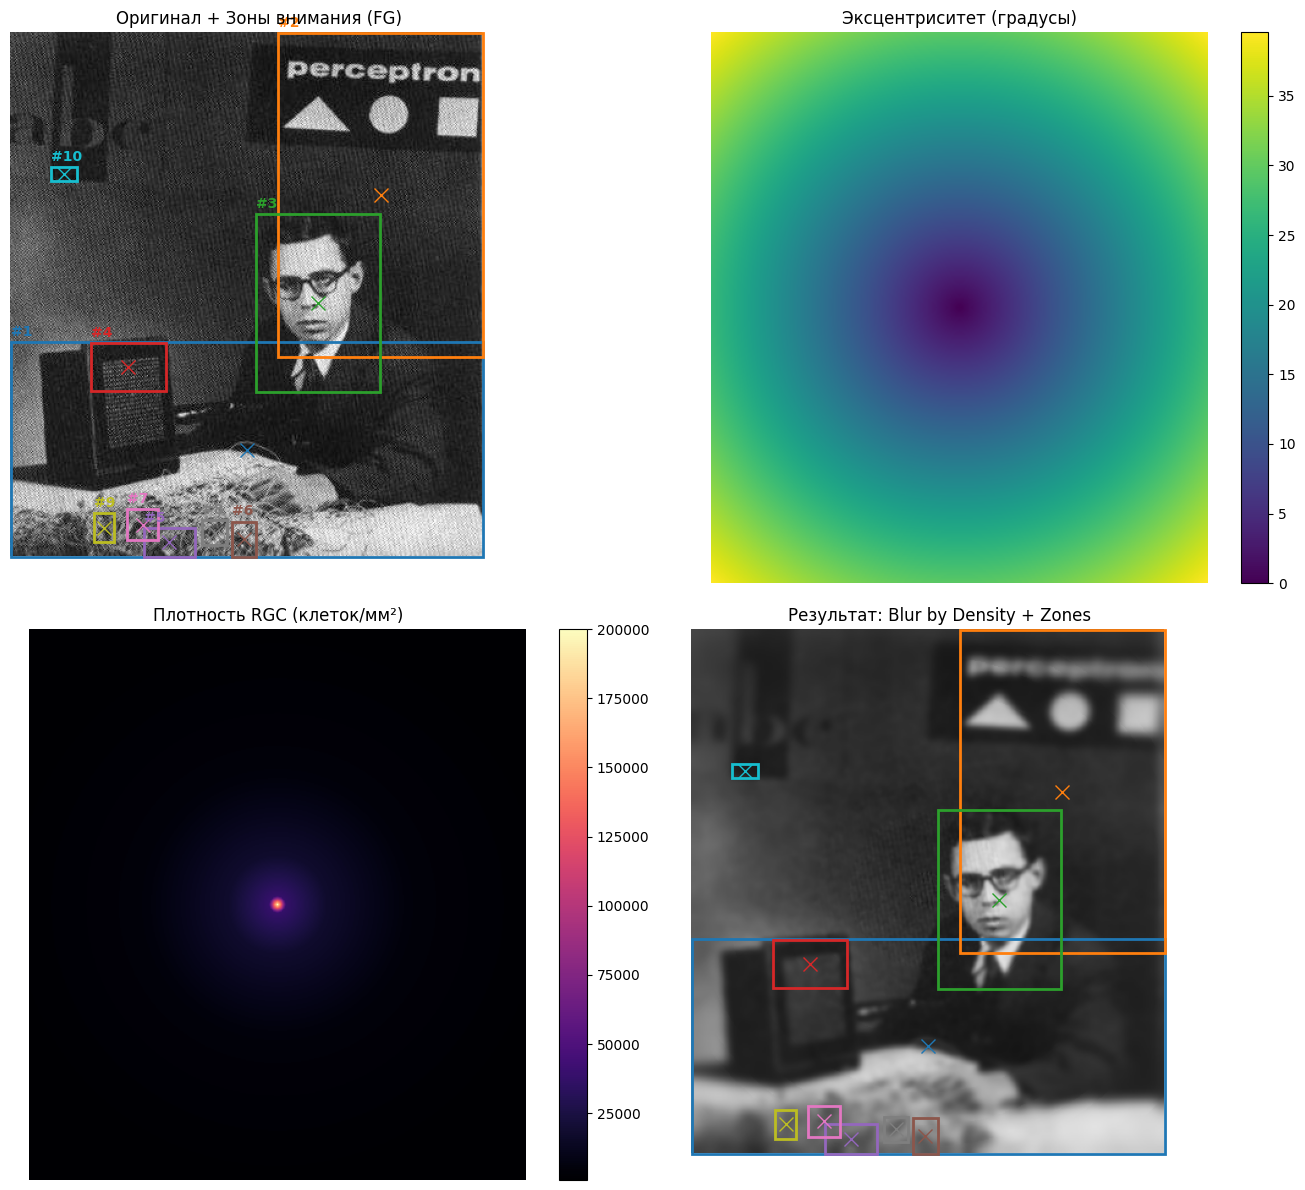

In [4]:
# =======================================
# Поиск зон (карт) внимания
# =======================================

img_path = str(input("Путь к изображению (или Enter для синтетики): "))

if img_path and Path(img_path).exists():
    image = cv2.imread(str(img_path))
    if image is None:
        raise FileNotFoundError("Не удалось загрузить изображение")
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    print("Изображение загружено.")
else:
    # Синтетическое изображение, если файл не найден или путь пуст
    print("Используется синтетическое изображение.")
    h_syn, w_syn = 512, 512
    image_rgb = np.zeros((h_syn, w_syn, 3), dtype=np.uint8)
    # Шахматная доска
    for i in range(0, h_syn, 32):
        for j in range(0, w_syn, 32):
            if (i // 32 + j // 32) % 2 == 0:
                image_rgb[i:i+32, j:j+32] = [200, 200, 200]
    # Яркий объект в центре
    cv2.circle(image_rgb, (w_syn//2, h_syn//2), 50, (0, 255, 0), -1)
    # Яркие объекты по краям
    cv2.rectangle(image_rgb, (10, 10), (60, 60), (255, 0, 0), -1)
    cv2.rectangle(image_rgb, (w_syn-60, h_syn-60), (w_syn-10, h_syn-10), (0, 0, 255), -1)

# Вычисление карт значимости
print("Вычисление StaticSaliency FineGrained...")
saliency_fg = cv2.saliency.StaticSaliencyFineGrained_create()
(success_fg, saliencyMap_fg) = saliency_fg.computeSaliency(image_rgb)

print("Вычисление StaticSaliency SpectralResidual...")
saliency_sr = cv2.saliency.StaticSaliencySpectralResidual_create()
(success_sr, saliencyMap_sr) = saliency_sr.computeSaliency(image_rgb)

def find_objects_from_saliency(saliency_map, max_objects=20):
    """Находит top-N объектов на основе карты значимости"""
    if saliency_map is None or not np.any(saliency_map):
        return []
    
    # Нормализация к 0-255
    saliency_normalized = (saliency_map * 255).astype("uint8")
    
    # Бинаризация (Otsu)
    thresh = cv2.threshold(saliency_normalized, 0, 255, 
                          cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
    
    # Морфологическое закрытие, чтобы убрать шум
    kernel = np.ones((3,3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    
    # Нахождение контуров
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Сортировка по площади (убывание)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:max_objects]
    
    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        # Фильтр на мелкие боксы
        if w > 5 and h > 5:
            boxes.append((x, y, w, h))
            
    return boxes

boxes_attention_fg = find_objects_from_saliency(saliencyMap_fg, max_objects=50)
boxes_attention_sr = find_objects_from_saliency(saliencyMap_sr, max_objects=50)
print(f"Найдено {len(boxes_attention_fg)} зон внимания (FineGrained) и {len(boxes_attention_sr)} зон внимания (SpectralResidual)")
if len(boxes_attention_fg) < 5:
    boxes_attention = boxes_attention_fg + boxes_attention_sr
else:
    boxes_attention = boxes_attention_fg


# =======================================
# Размытие по эксцентриситету RGC
# =======================================

# Параметр числа зон внимания
boxes_num = 10

# Параметры экрана и зрения
screen_width = 600      # мм
view_dist = 600         # мм
base_sigma = 0.2        # минимальное размытие (фовеола)
scale_density = 150.0   # коэффициент влияния плотности

# Таблица плотности RGC (клеток/мм^2) от эксцентриситета на сетчатке (мм)
ecc_mm_data = np.array([0.0, 0.25, 1.5, 4.0, 5.0, 9.0, 15.0, 17.0])
density_data = np.array([200000, 38000, 18000, 5000, 3900, 1000, 800, 400])

density_interp = interp1d(
    ecc_mm_data, density_data,
    kind='linear',
    bounds_error=False,
    fill_value=(density_data[0], density_data[-1])
)

# Карта яркости (Luminance)
def get_luminance(img_rgb):
    return np.dot(img_rgb[..., :3], [0.2126, 0.7152, 0.0722])

def calculate_deg_per_px(screen_w, view_dist, img_w):
    half_width_mm = screen_w / 2.0
    angle_rad = math.atan(half_width_mm / view_dist)
    full_angle_deg = 2 * angle_rad * (180.0 / math.pi)
    return full_angle_deg / img_w

def mm_from_deg(ecc_deg):
    return ecc_deg * 0.288 # Приблизительный масштаб сетчатки

def sigma_from_density(density_val):
    spacing = 1.0 / np.sqrt(np.maximum(density_val, 1.0))
    return base_sigma + scale_density * spacing

def eccentricity_blur_with_density(img, center, deg_per_px):
    h, w = img.shape[:2]
    
    # Карта расстояний в пикселях от центра
    y, x = np.ogrid[:h, :w]
    dist_px = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    
    # Перевод в градусы зрительного угла
    ecc_deg_map = dist_px * deg_per_px
    
    # Перевод в мм на сетчатке
    ecc_mm_map = mm_from_deg(ecc_deg_map)
    
    # Карта плотности RGC
    density_map = density_interp(ecc_mm_map)
    
    # Карта Sigma (размытия)
    sigma_map = sigma_from_density(density_map)
    
    # Оптимизированное размытие:
    # Так как GaussianBlur дорогой, мы не можем делать его для каждого пикселя.
    # Поэтому усредненный подход по зонам или адаптивное ядро.
    # Для простоты и скорости сделаем дискретизацию по уровням sigma.
    
    unique_sigmas = np.unique(np.round(sigma_map, 1))
    result = np.zeros_like(img, dtype=np.float64)
    weight = np.zeros((h, w), dtype=np.float64)
    
    # Группируем похожие сигмы, чтобы не делать 100 разных блюров
    # Шаг квантования сигмы
    step = 0.5 
    min_s = np.min(sigma_map)
    max_s = np.max(sigma_map)
    
    current_sigma = min_s
    while current_sigma <= max_s:
        next_sigma = current_sigma + step
        # Маска для текущей полосы сигм
        mask = (sigma_map >= current_sigma) & (sigma_map < next_sigma)
        
        if np.any(mask):
            ksize = int(6 * current_sigma + 1) | 1
            ksize = max(3, ksize)
            
            # Размываем все изображение с текущей сигмой
            blurred_patch = cv2.GaussianBlur(img, (ksize, ksize), sigmaX=current_sigma)
            
            result[mask] += blurred_patch[mask]
            weight[mask] += 1.0
            
        current_sigma = next_sigma
        
    # Нормализация (на случай перекрытий, хотя здесь они исключены масками)
    weight = np.maximum(weight, 1e-6)
    final_img = result / weight[..., None]
    
    return np.clip(final_img, 0, 255).astype(np.uint8), ecc_deg_map, density_map

# Расчет параметров
h, w = image_rgb.shape[:2]
center = (w // 2, h // 2)
deg_per_px = calculate_deg_per_px(screen_width, view_dist, w)
luminance_map = get_luminance(image_rgb)

print(f"Размер: {w}x{h}, Центр: {center}, Deg/Px: {deg_per_px:.4f}")

# Размытие
blurred_image, ecc_map, dens_map = eccentricity_blur_with_density(image_rgb, center, deg_per_px)

# =======================================
# Яркость адаптации
# =======================================

def calculate_adaptation_luminance(boxes, lum_map, den_map):
    """
    Считает средневзвешенную яркость для изображения.
    Весом выступает плотность клеток (RGC).
    """
    # сумма весов (сумма плотностей пикселей=клеток в зоне) всех зон
    total_weight = 0.00
    total_lum = 0.00
    
    for box in boxes:
        
        x, y, bw, bh = box
        
        # Обрезка границ
        y_end = min(y + bh, lum_map.shape[0])
        x_end = min(x + bw, lum_map.shape[1])
        
        zone_lum = lum_map[y:y_end, x:x_end]
        zone_den = den_map[y:y_end, x:x_end]
        
        # Взвешенное среднее: Sum(L * D) / Sum(D)
        weighted_sum = np.sum(zone_lum * zone_den)
        weight_zone = np.sum(zone_den)
        total_weight += weight_zone

        total_lum += np.sum(zone_lum * zone_den) 
        
    if total_weight == 0: 
        return 0, weight_zone
        
    return total_lum / total_weight

Adaptation_lum = calculate_adaptation_luminance(
    boxes_attention, luminance_map, dens_map
)
print(f"Яркость адаптации = {Adaptation_lum:.2f}")

# =======================================
# Визуализация
# =======================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Оригинал с зонами внимания
axes[0, 0].imshow(image_rgb)
axes[0, 0].set_title("Оригинал + Зоны внимания (FG)")
axes[0, 0].axis('off')
# Отрисовка боксов зон внимания
colors = plt.cm.tab10(np.linspace(0, 1, len(boxes_attention[:boxes_num])))
for i, (x, y, bw, bh) in enumerate(boxes_attention[:boxes_num]):
    rect = plt.Rectangle((x, y), bw, bh, linewidth=2, edgecolor=colors[i], facecolor='none')
    axes[0, 0].add_patch(rect)
    cx, cy = x + bw/2, y + bh/2
    axes[0, 0].plot(cx, cy, 'x', color=colors[i], markersize=10)
    axes[0, 0].text(x, y-5, f'#{i+1}', color=colors[i], fontweight='bold')

# Карта эксцентриситета
im1 = axes[0, 1].imshow(ecc_map, cmap='viridis')
axes[0, 1].set_title("Эксцентриситет (градусы)")
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

# Карта плотности RGC
im2 = axes[1, 0].imshow(dens_map, cmap='magma')
axes[1, 0].set_title("Плотность RGC (клеток/мм²)")
axes[1, 0].axis('off')
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046)

# Размытое изображение с теми же зонами внимания
axes[1, 1].imshow(blurred_image)
axes[1, 1].set_title("Результат: Blur by Density + Zones")
axes[1, 1].axis('off')
# зоны внимания на размытом изображении
adaptation_brightness = 0
for i, (x, y, bw, bh) in enumerate(boxes_attention[:boxes_num]):
    rect = plt.Rectangle((x, y), bw, bh, linewidth=2, edgecolor=colors[i], facecolor='none')
    axes[1, 1].add_patch(rect)
    cx, cy = x + bw/2, y + bh/2
    axes[1, 1].plot(cx, cy, 'x', color=colors[i], markersize=10)

plt.tight_layout()
plt.show()

In [5]:
image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
np.mean(image_gray)

np.float64(69.11215915867079)

## Адаптивное размытие

In [11]:
# Пример оригинального изображения

In [12]:
img = cv2.imread("Rosenblatt.jpg")
image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_norm = image.astype(np.float32) / 255.0
img_chw = np.transpose(img_norm, (2, 0, 1))
img_tensor = torch.from_numpy(img_chw).unsqueeze(0)

(np.float64(-0.5), np.float64(386.5), np.float64(428.5), np.float64(-0.5))

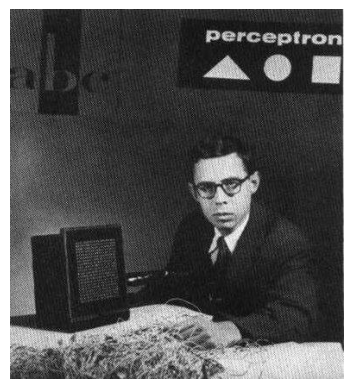

In [15]:
plt.imshow(image)
plt.axis("off")

In [16]:
# Механизм размытия изображения на основе плотности RGC в зависимости от эксцентриситета

In [10]:
# =======================================
# Настраиваемые параметры 
# =======================================
img_path = None   # путь к картинке либо синтетическое изображение в случае None
center = None                  # (x, y) центр внимания. В случае None - центр изображения
# deg_per_px = 0.05              # градусов зрительного угла на 1 пиксель. 
                               # Переводит расстояние в пиксельях в эксцентриситет
zones = [0, 2, 5, 10, 20, 40]  # границы зон эксцентриситета в градусах

screen_width = 600              # физическая ширина экрана (мм)
view_dist = 600                 # расстояние от глаз до экрана (мм)


# Параметры размытия на основе плотности
base_sigma = 0.2               # минимальное размытие (фовеола)
scale = 150.0                  # параметр уровня влияния плотности на размытие 

# =======================================
# Таблица плотности RGC (клеток/мм^2)
# =======================================
# Данные по литературе 
# (см. https://docs.google.com/document/d/1Zw-1r1arVRw8uKVHQfwoThZuA3vbuiV6M_dMN-vRmK0/edit?tab=t.sau0s02p1xqn#bookmark=id.e1qczzd60vj0)
ecc_mm = np.array([0.0, 0.25, 1.5, 4.0, 5.0, 9.0, 15.0, 17.0])
density = np.array([200000, 38000, 18000, 5000, 3900, 1000, 800, 400])

density_interp = interp1d(
    ecc_mm, density,
    kind='linear',
    bounds_error=False,
    fill_value=(density[0], density[-1])
)

# =======================================
# Вспомогательные функции
# =======================================
def calculate_deg_per_px(screen_w, view_dist, img_w):
    """
    Рассчитывает, сколько градусов зрительного угла приходится на 1 пиксель.
    формула: deg_per_px = (2 * arctan((screen_w / 2) / view_dist) * 180/π) / img_w
    """
    half_width_mm = screen_w / 2.0
    angle_rad = math.atan(half_width_mm / view_dist)
    full_angle_deg = 2 * angle_rad * (180.0 / math.pi)
    deg_per_px = full_angle_deg / img_w
    return deg_per_px
    
def create_synthetic_image(h=512, w=512):
    img = np.zeros((h, w, 3), dtype=np.uint8)

    # Шахматная доска
    for i in range(0, h, 16):
        for j in range(0, w, 16):
            if (i // 16 + j // 16) % 2 == 0:
                img[i:i+16, j:j+16] = 220

    # Круги вокруг центра
    cy, cx = h // 2, w // 2
    for r in range(20, min(h, w) // 2, 25):
        cv2.circle(img, (cx, cy), r, (0, 180, 255), 2)

    # Линии разной частоты
    for x in range(0, w, 8):
        cv2.line(img, (x, 0), (x, h), (80, 80, 80), 1)
    for y in range(0, h, 12):
        cv2.line(img, (0, y), (w, y), (80, 80, 80), 1)

    return img

def mm_from_deg(ecc_deg):
    """Перевод в мм: ~0.288 мм сетчатки на 1 градус"""
    return ecc_deg * 0.288

def sigma_from_density(density, base_sigma=base_sigma, scale=scale):
    """
    Чем ниже плотность клеток -> тем больше средний размер рецептивного поля -> больше sigma.
    Среднее расстояние между клеткамиее = 1 / sqrt(density)
    """
    spacing = 1.0 / np.sqrt(np.maximum(density, 1.0))  # мм
    return base_sigma + scale * spacing

def eccentricity_blur_with_density(img, center, deg_per_px=deg_per_px, zones=zones):
    """
    Основная функция размытия с использованием таблицы плотности RGC.
    """
    h, w = img.shape[:2]
    if center is None:
        center = (w // 2, h // 2)

    # Карта эксцентриситета
    y, x = np.ogrid[:h, :w]
    dist_px = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    ecc_deg = dist_px * deg_per_px
    ecc_mm = mm_from_deg(ecc_deg)

    # Карта плотности
    density_map = density_interp(ecc_mm)

    result = np.zeros_like(img, dtype=np.float32)
    weight = np.zeros((h, w), dtype=np.float32)

    for i in range(len(zones) - 1):
        low, high = zones[i], zones[i + 1]
        mask = (ecc_deg >= low) & (ecc_deg < high)
        if not np.any(mask):
            continue

        # Средняя плотность в зоне = сигма
        mean_density = float(np.mean(density_map[mask]))
        sigma = sigma_from_density(mean_density)

        ksize = int(6 * sigma + 1) | 1
        ksize = max(3, ksize)

        blurred = cv2.GaussianBlur(img, (ksize, ksize), sigmaX=sigma, sigmaY=sigma)

        result[mask] += blurred[mask]
        weight[mask] += 1.0

    weight = np.maximum(weight, 1e-6)
    result = result / weight[..., None]

    return np.clip(result, 0, 255).astype(np.uint8), ecc_deg, density_map

In [182]:
# Визуализация

Используется синтетическое изображение
Размер изображения : 512×512
Центр внимания     : (256, 256)
Ширина экрана      : (256, 256)
Расстояние наблюдения: (256, 256)
Градусов на пиксель: 0.1037697311604609
base_sigma / scale : 0.2 / 150.0


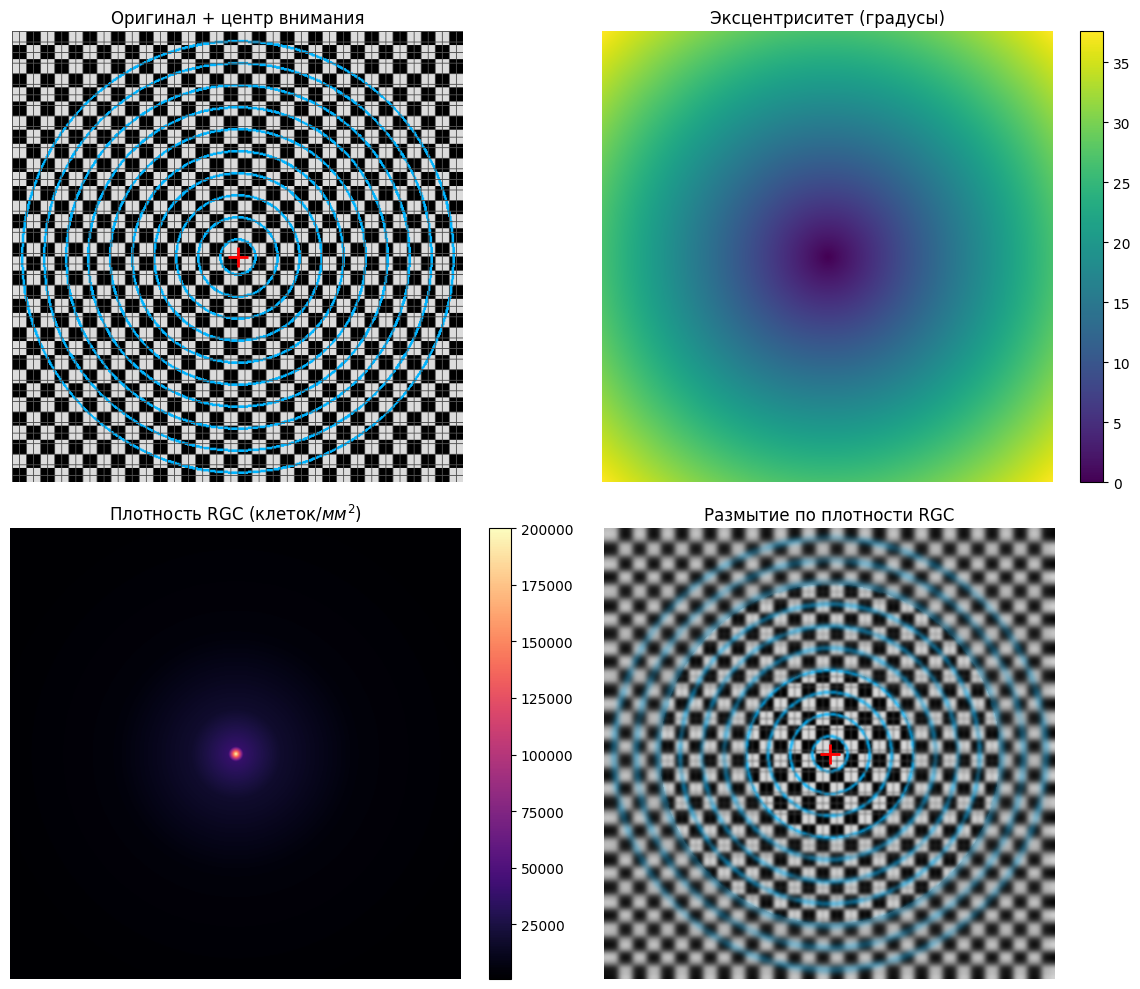

In [42]:
# Загрузка или создание изображения
if img_path and Path(img_path).exists():
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print("Используется загруженное изображение")
else:
    print("Используется синтетическое изображение")
    img = create_synthetic_image(512, 512)

h, w = img.shape[:2]
center = center if center is not None else (w // 2, h // 2)

# ============================
# Расчет deg_per_px
deg_per_px = calculate_deg_per_px(
    screen_w=screen_width,
    view_dist=view_dist,
    img_w = w
)
# ============================

print(f"Размер изображения : {w}×{h}")
print(f"Центр внимания     : {center}")
print(f"Ширина экрана      : {center}")
print(f"Расстояние наблюдения: {center}")
print(f"Градусов на пиксель: {deg_per_px}")
print(f"base_sigma / scale : {base_sigma} / {scale}")

# Размытие
blurred, ecc_map, density_map = eccentricity_blur_with_density(img, center, deg_per_px)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Оригинал
axes[0, 0].imshow(img)
axes[0, 0].plot(center[0], center[1], 'r+', markersize=14, markeredgewidth=2)
axes[0, 0].set_title("Оригинал + центр внимания")
axes[0, 0].axis("off")

# Карта эксцентриситета
im1 = axes[0, 1].imshow(ecc_map, cmap="viridis")
axes[0, 1].set_title("Эксцентриситет (градусы)")
axes[0, 1].axis("off")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

# Карта плотности RGC
im2 = axes[1, 0].imshow(density_map, cmap="magma")
axes[1, 0].set_title(r"Плотность RGC (клеток/$мм^2$)")
axes[1, 0].axis("off")
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046)

# Результат размытия
axes[1, 1].imshow(blurred)
axes[1, 1].plot(center[0], center[1], 'r+', markersize=14, markeredgewidth=2)
axes[1, 1].set_title("Размытие по плотности RGC")
axes[1, 1].axis("off")

plt.tight_layout()
# plt.savefig("blur_density_demo.png", dpi=150, bbox_inches="tight")
# print("\nРезультат сохранён в: blur_density_demo.png")
# cv2.imwrite("blurred_result.png", cv2.cvtColor(blurred, cv2.COLOR_RGB2BGR))
# print("Размытое изображение: blurred_result.png")

plt.show()

In [22]:
blurred

array([[[187, 187, 187],
        [188, 188, 188],
        [188, 188, 188],
        ...,
        [ 12,  12,  12],
        [ 12,  12,  12],
        [ 12,  12,  12]],

       [[188, 188, 188],
        [189, 189, 189],
        [189, 189, 189],
        ...,
        [ 12,  12,  12],
        [ 11,  11,  11],
        [ 11,  11,  11]],

       [[189, 189, 189],
        [190, 190, 190],
        [190, 190, 190],
        ...,
        [ 11,  11,  11],
        [ 11,  11,  11],
        [ 10,  10,  10]],

       ...,

       [[ 14,  14,  14],
        [ 13,  13,  13],
        [ 13,  13,  13],
        ...,
        [208, 208, 208],
        [209, 209, 209],
        [210, 210, 210]],

       [[ 13,  13,  13],
        [ 13,  13,  13],
        [ 13,  13,  13],
        ...,
        [209, 209, 209],
        [210, 210, 210],
        [211, 211, 211]],

       [[ 13,  13,  13],
        [ 12,  12,  12],
        [ 12,  12,  12],
        ...,
        [210, 210, 210],
        [211, 211, 211],
        [211, 211, 211]]

In [23]:
img

array([[[ 80,  80,  80],
        [ 80,  80,  80],
        [ 80,  80,  80],
        ...,
        [ 80,  80,  80],
        [ 80,  80,  80],
        [ 80,  80,  80]],

       [[ 80,  80,  80],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[ 80,  80,  80],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[ 80,  80,  80],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       [[ 80,  80,  80],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       [[ 80,  80,  80],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]]

## Графики распределений клеток

In [65]:
# density_rgc = np.array([200_000, 38_000, 18_000, 5_000, 1_000, 800]) 
# density_bc = np.array([150_000, 70_000, 25_000, 15_000, 7_000, 4_000])
# density_hc = np.array([0, 23_000, 10_000, 4_000, 2_500, 1_500])
# ecc = np.array([0.0, 0.3, 1.5, 4.5, 9.0, 15.0])
# names = ['Ганглионарные клетки', 'Биполярные клетки',  'Горизонтальные клетки']

In [149]:
density_rgc = np.array([38_000, 18_000, 5_000, 1_000, 800]) 
density_bc = np.array([70_000, 25_000, 15_000, 7_000, 4_000])
density_hc = np.array([23_000, 10_000, 4_000, 2_500, 1_500])
ecc = np.array([0.3, 1.5, 4.5, 9.0, 15.0])

In [150]:
density_hc

array([23000, 10000,  4000,  2500,  1500])

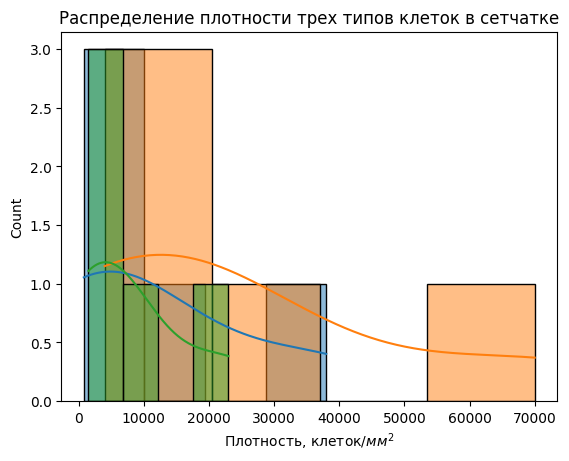

In [145]:
sns.histplot(density_rgc , kde=True)
sns.histplot(density_bc, kde=True)
sns.histplot(density_hc, kde=True)
plt.xlabel(r"Плотность, клеток/$мм^2$")
plt.title("Распределение плотности трех типов клеток в сетчатке")
plt.show();

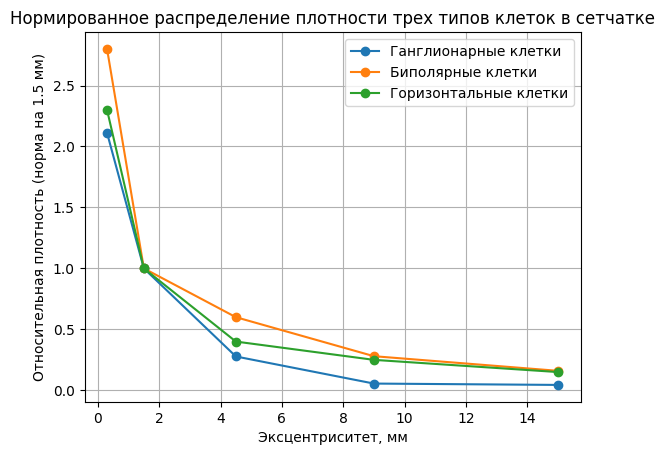

In [64]:
plt.plot(ecc, density_rgc / density_rgc[1], marker='o', label = "Ганглионарные клетки")
plt.plot(ecc, density_bc / density_bc[1], marker='o', label = "Биполярные клетки")
plt.plot(ecc, density_hc / density_hc[1], marker='o', label = "Горизонтальные клетки")
plt.xlabel("Эксцентриситет, мм")
plt.ylabel(r"Относительная плотность (норма на 1.5 мм)")
plt.legend()
plt.title("Нормированное распределение плотности трех типов клеток в сетчатке")
plt.grid()
plt.show();

In [153]:
def hb(a, x, b):
    return 1 / (a * x + b)

In [154]:
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error

In [179]:
params, cov = curve_fit(hb, density_rgc, ecc)
a, b = params
y_fit = hb(a, density_rgc, b)
mean_squared_error(ecc, y_fit)

2.2888380840001754

In [176]:
params_bc, cov_bc = curve_fit(hb, density_bc, ecc)
a_bc, b_bc = params_bc
y_fit_bc = hb(a_bc, density_bc, b_bc)
mean_squared_error(ecc, y_fit_bc)

0.3041130918678493

In [180]:
params_hc, cov_hc = curve_fit(hb, density_hc, ecc)
a_hc, b_hc = params
y_fit_hc = hb(a_hc, density_hc, b_hc)
mean_squared_error(ecc, y_fit_hc)

10.76508117620482

C:\Users\Лиза\AppData\Local\Temp\ipykernel_19812\2033314568.py:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(density_rgc, y_fit, 'r-', color='blue', label=f'Аппроксимация RGC: y = 1/({a:.2f}x + {b:.2f})')
C:\Users\Лиза\AppData\Local\Temp\ipykernel_19812\2033314568.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(density_bc, y_fit_bc, 'r-', color='orange', label=f'Аппроксимация BC: y = 1/({a_bc:.2f}x + {b_bc:.2f})')
C:\Users\Лиза\AppData\Local\Temp\ipykernel_19812\2033314568.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(density_hc, y_fit_hc, 'r-', color='green', label=f'Аппроксимация HC: y = 1/({a_hc:.2f}x + {b_hc:.

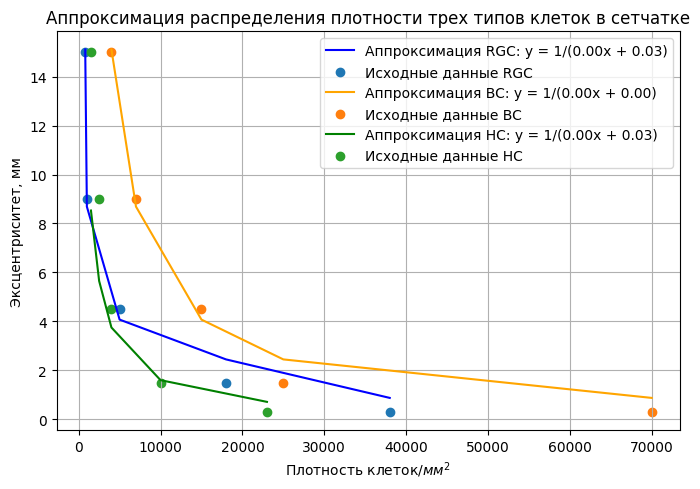

In [174]:
plt.figure(figsize=(7,5))
plt.plot(density_rgc, y_fit, 'r-', color='blue', label=f'Аппроксимация RGC: y = 1/({a:.2f}x + {b:.2f})')
plt.scatter(density_rgc, ecc, label='Исходные данные RGC')

plt.plot(density_bc, y_fit_bc, 'r-', color='orange', label=f'Аппроксимация BC: y = 1/({a_bc:.2f}x + {b_bc:.2f})')
plt.scatter(density_bc, ecc, label='Исходные данные BC')

plt.plot(density_hc, y_fit_hc, 'r-', color='green', label=f'Аппроксимация HC: y = 1/({a_hc:.2f}x + {b_hc:.2f})')
plt.scatter(density_hc, ecc, label='Исходные данные HC')

plt.xlabel(r"Плотность клеток/$мм^2$")
plt.ylabel("Эксцентриситет, мм")
plt.grid()
plt.legend()
plt.title("Аппроксимация распределения плотности трех типов клеток в сетчатке")
plt.tight_layout()
plt.show();